In [10]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


In [11]:

df = pd.read_csv('C:\\Users\\AA.Y TRADEERS\\Downloads\\Data.csv\\.venv\\insurance_data.csv')

df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


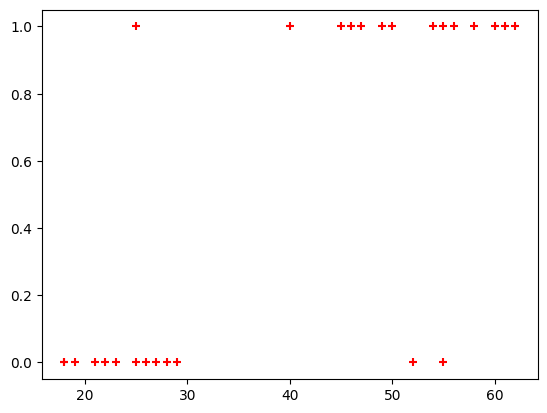

In [12]:
plt.scatter(df.age,df.bought_insurance,marker = '+',color='red')

In [13]:
df.shape
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(df[['age']],df.bought_insurance,test_size=0.2,random_state=42)
x_test

,age
8,62
13,29
9,61
21,26
0,22
11,28


In [14]:
x_train

,age
16,25
17,58
12,27
24,50
1,25
4,46
5,56
2,47
15,55
22,40


c:\Users\AA.Y TRADEERS\Downloads\Data.csv\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


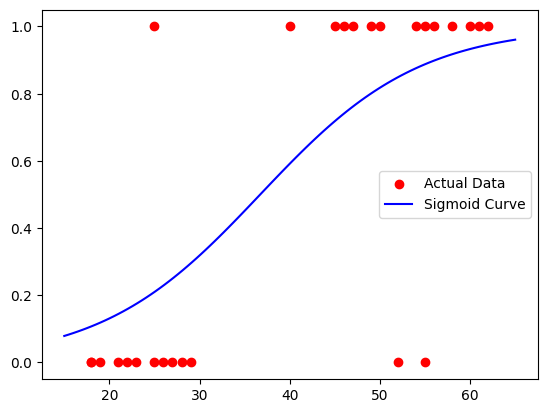

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
plt.scatter(df.age, df.bought_insurance, color='red', label='Actual Data')

# 2. Smooth Blue Sigmoid Line banana
X_smooth = np.linspace(15, 65, 100).reshape(-1, 1)
y_prob = model.predict_proba(X_smooth)[:, 1] # Probability nikalna
plt.plot(X_smooth, y_prob, color='blue', label='Sigmoid Curve')

# 3. Graph show karna
plt.legend()
plt.show()

In [16]:
model.predict(x_test)

array([1, 0, 1, 0, 0, 0])

In [17]:
model.score(x_test,y_test)

1.0

In [18]:

import gradio as gr
import numpy as np
import matplotlib.pyplot as plt

# 1. Yeh function prediction text aur graph dono UI ko dega
def check_insurance_with_graph(user_age):
    # Prediction logic
    prediction = model.predict([[user_age]])
    if prediction == 1:
        result_text = "YES (Customer will buy insurance)"
    else:
        result_text = "NO (Customer will not buy insurance)"
        
    # --- GRAPH CODE ---
    fig = plt.figure(figsize=(5, 3.5)) # Naya khali graph frame banayein
    
    # Asal data ke points (Red Dots)
    plt.scatter(df.age, df.bought_insurance, color='red', label='Actual Data')
    
    # Smooth Blue Sigmoid Line
    X_smooth = np.linspace(15, 65, 100).reshape(-1, 1)
    y_prob = model.predict_proba(X_smooth)[:, 1]
    plt.plot(X_smooth, y_prob, color='blue', label='Sigmoid Curve')
    plt.legend()
    
    # Text aur Graph dono ko UI ki taraf bhejein
    return result_text, fig

# 2. Gradio Interface (Outputs mein humne Text aur Plot dono rakh diye hain)
ui = gr.Interface(
    fn=check_insurance_with_graph, 
    inputs=gr.Number(label="Enter Customer Age:"), 
    outputs=[
        gr.Text(label="Prediction Result:"), 
        gr.Plot(label="Sigmoid Analysis Graph") # Graph dikhane ka box
    ],
    title="Insurance Predictor",
    description="Enter age to see prediction and curve."
)

ui.launch(inline=True, share=True)




* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://5ca477a4731782f797.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
